# Dia 2 · Módulo 6 — Correlação não é causalidade
### Estatística Básica Aplicada · Python

Nos Módulos 4 e 5, toda vez que alguém deu o passo seguinte — *"então o treino **causa** a
melhora"* — nós paramos e adiamos. Este módulo é essa conversa adiada.

> ## Quando é que eu posso dizer que A causa B?
> ## E por que quase nenhum dado observacional me autoriza a dizer isso?

A frase "correlação não é causalidade" todo mundo repete. O que quase ninguém sabe é **como** a
correlação engana — e são mecanismos diferentes, que exigem defesas diferentes.

**O que a turma vai levar deste módulo:**
1. Duas variáveis podem andar juntas por **quatro** motivos, e só um deles é causa.
2. **Confundimento**: a terceira variável que causa as duas.
3. **Paradoxo de Simpson**: o agregado que inverte o sinal de **todos** os subgrupos.
4. **Colisor**: a correlação que **você mesmo cria** ao escolher quem entra na amostra.
5. Só o **sorteio** (aleatorização) resolve o problema de uma vez — e por que ele é raro.

> ⚠️ Você não precisa escrever código do zero: **ler → prever → rodar → interpretar → modificar**.

## Roteiro e tempo

| Seção | Assunto | Ideia central |
|---|---|---|
| ⓪ | Correlação espúria | duas séries que sobem juntas e não se conhecem |
| ① | Os quatro motivos | só um é causa |
| ② | Confundimento | a terceira variável |
| ③ | Paradoxo de Simpson | o agregado mente sobre os grupos |
| ④ | Colisor | a correlação que a sua amostra fabricou |
| ⑤ | O que autoriza falar em causa | o sorteio |
| ⑥ | Decisão + fechamento do Dia 2 | |

Nenhuma seção deste módulo é dispensável. Se o tempo apertar, corte profundidade — não corte
seções: cada uma é um mecanismo **diferente** de engano.

In [1]:
# --- Preparação do ambiente ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

COR = {
    "media":   "#2a78d6",   # azul
    "mediana": "#eb6834",   # laranja
    "dados":   "#9ec5f4",   # azul claro
    "reta":    "#2a78d6",
    "alerta":  "#e34948",   # vermelho — o engano
    "verdade": "#1baf7a",   # verde    — o valor real
    "grupoA":  "#4a3aa7",   # violeta
    "grupoB":  "#eb6834",   # laranja
}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.labelcolor": "#52514e", "xtick.color": "#898781", "ytick.color": "#898781",
    "font.size": 10, "lines.linewidth": 2, "figure.dpi": 110,
})

print("Ambiente pronto.")

Ambiente pronto.


---
# ⓪ Duas séries que nunca se encontraram

O S3 cruzou dois indicadores da OM ao longo de 14 anos e encontrou `r = 0,97`. O relatório
sugere que o aumento do consumo de material de expediente vem "acompanhando o crescimento da
capacidade operacional".

**Antes de rodar:** o que mais poderia fazer dois indicadores quaisquer subirem juntos durante
14 anos seguidos?

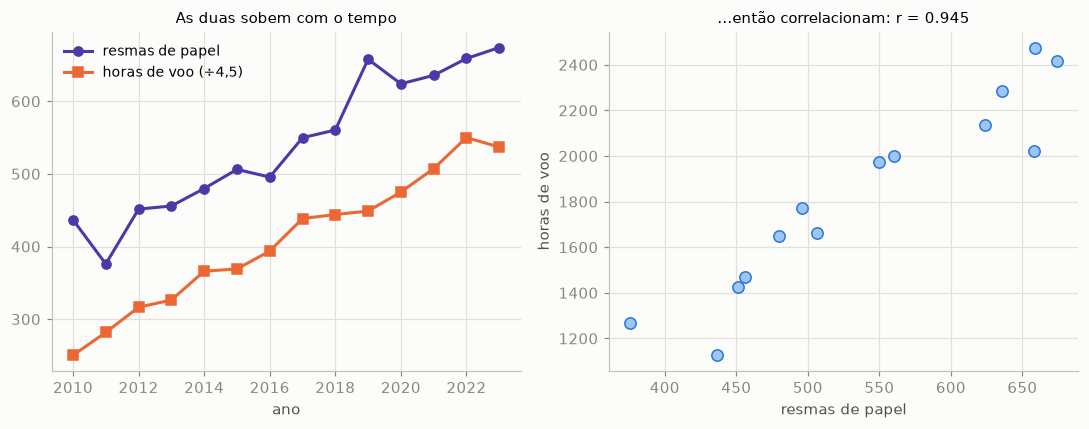

r = 0.945  —  'praticamente perfeita'

E não há relação nenhuma: papel não põe avião no ar, e avião não gasta resma.
As duas só têm em comum o TEMPO. Qualquer par de coisas que cresça ao longo dos anos
vai correlacionar — orçamento, população, preço do café, número de celulares.

Esse é o caso mais fácil de perceber. Os próximos são bem menos óbvios.


In [2]:
# --- Duas séries sem NENHUMA relação entre si ---
anos = np.arange(2010, 2024)
rng = np.random.default_rng(3)

# as duas apenas CRESCEM com o tempo, cada uma pelo seu próprio motivo
resmas_papel = 400 + 22 * (anos - 2010) + rng.normal(0, 18, len(anos))   # inflação, mais efetivo
horas_voo    = 1200 + 95 * (anos - 2010) + rng.normal(0, 70, len(anos))  # novas aeronaves

r_espuria = stats.pearsonr(resmas_papel, horas_voo).statistic

fig, (e1, e2) = plt.subplots(1, 2, figsize=(10, 4))
e1.plot(anos, resmas_papel, color=COR["grupoA"], marker="o", label="resmas de papel")
e1.plot(anos, horas_voo / 4.5, color=COR["grupoB"], marker="s", label="horas de voo (÷4,5)")
e1.set_title("As duas sobem com o tempo", fontsize=10)
e1.set_xlabel("ano"); e1.legend(frameon=False, fontsize=9)

e2.scatter(resmas_papel, horas_voo, color=COR["dados"], edgecolor=COR["reta"], s=55, zorder=3)
e2.set_title(f"...então correlacionam: r = {r_espuria:.3f}", fontsize=10)
e2.set_xlabel("resmas de papel"); e2.set_ylabel("horas de voo")

plt.tight_layout()
plt.show()

print(f"r = {r_espuria:.3f}  —  'praticamente perfeita'")
print("\nE não há relação nenhuma: papel não põe avião no ar, e avião não gasta resma.")
print("As duas só têm em comum o TEMPO. Qualquer par de coisas que cresça ao longo dos anos")
print("vai correlacionar — orçamento, população, preço do café, número de celulares.")
print("\nEsse é o caso mais fácil de perceber. Os próximos são bem menos óbvios.")

---
# ① Os quatro motivos para duas variáveis andarem juntas

Quando você observa que **A** e **B** correlacionam, existem exatamente quatro explicações
possíveis — e três delas **não** são "A causa B":

| # | Motivo | Exemplo na caserna | Como se defender |
|---|---|---|---|
| 1 | **A causa B** | treino reduz tempo de corrida | é o que você quer provar (§⑤) |
| 2 | **B causa A** (causalidade reversa) | quem já corre bem se anima a treinar mais | ordem no tempo |
| 3 | **C causa as duas** (confundimento) | idade afeta treino **e** tempo | medir e ajustar C (§②) |
| 4 | **acaso ou seleção** | `r` fabricado por n pequeno, filtro ou tendência comum | §⓪, §④ e Módulo 8 |

> ### 🔑 A ideia central do módulo
> O dado observacional, sozinho, **não consegue distinguir esses quatro casos**. Os números são
> compatíveis com todos eles ao mesmo tempo.
>
> Quem separa não é a estatística: é o **desenho do estudo** e o **conhecimento do assunto**.
> Nenhum cálculo, por mais sofisticado, transforma observação em causa.

A causalidade reversa (motivo 2) é a mais subestimada. "As OMs que mais fazem manutenção
preventiva são as que mais têm falhas" quase certamente é isso ao contrário: as que têm mais
falhas é que passaram a fazer mais preventiva.

---
# ② Confundimento: a terceira variável

O caso mais comum e mais perigoso, porque a correlação é **real**, o cálculo está **certo**, e a
conclusão está **errada**.

> O S4 observa: *"viaturas que recebem mais horas de manutenção apresentam MAIS falhas em
> operação. A manutenção está piorando as viaturas."*

**Antes de rodar:** que terceira variável poderia produzir esse resultado absurdo?

In [3]:
# --- Manutenção × falhas: a quilometragem por trás das duas ---
rng2 = np.random.default_rng(9)
NV = 240

km_ano = rng2.uniform(5_000, 60_000, NV)                          # o CONFUNDIDOR

# quanto mais roda, mais manutenção a viatura recebe...
manutencao = 8 + 0.00045 * km_ano + rng2.normal(0, 3.0, NV)       # horas/ano de manutenção

# ...e mais ela falha, PELO USO. A manutenção, essa, REDUZ as falhas (coeficiente negativo).
falhas = np.clip(
    1
    + 0.00022 * km_ano                                 # o uso ESTRAGA  (+)
    - 0.25 * (manutencao - manutencao.mean())          # a manutenção AJUDA (-)
    + rng2.normal(0, 0.5, NV),
    0, None)                                                       # falhas/ano

frota = pd.DataFrame({"km_ano": km_ano, "manutencao_h": manutencao, "falhas": falhas})

r_bruto = stats.pearsonr(manutencao, falhas).statistic

# agora olhamos DENTRO de faixas parecidas de quilometragem
frota["faixa_km"] = pd.cut(frota["km_ano"], bins=[0, 20_000, 35_000, 50_000, 100_000],
                           labels=["até 20 mil", "20-35 mil", "35-50 mil", "mais de 50 mil"])

print(f"CORRELAÇÃO BRUTA (manutenção × falhas): {r_bruto:+.3f}   -> 'manutenção causa falha'!\n")
print("Agora a MESMA correlação, dentro de cada faixa de quilometragem:")
print(f"{'faixa de km/ano':<18} | {'viaturas':>8} | {'r dentro da faixa':>18}")
print("-" * 52)
for faixa, grupo in frota.groupby("faixa_km", observed=True):
    r_f = stats.pearsonr(grupo["manutencao_h"], grupo["falhas"]).statistic
    print(f"{str(faixa):<18} | {len(grupo):>8} | {r_f:>+18.3f}")

print("\nDentro de cada faixa o sinal se INVERTE: comparando viaturas que rodam o mesmo,")
print("mais manutenção significa MENOS falhas — que é o que a engenharia sempre disse.")

CORRELAÇÃO BRUTA (manutenção × falhas): +0.623   -> 'manutenção causa falha'!

Agora a MESMA correlação, dentro de cada faixa de quilometragem:
faixa de km/ano    | viaturas |  r dentro da faixa
----------------------------------------------------
até 20 mil         |       55 |             -0.330
20-35 mil          |       66 |             -0.381
35-50 mil          |       77 |             -0.442
mais de 50 mil     |       42 |             -0.618

Dentro de cada faixa o sinal se INVERTE: comparando viaturas que rodam o mesmo,
mais manutenção significa MENOS falhas — que é o que a engenharia sempre disse.


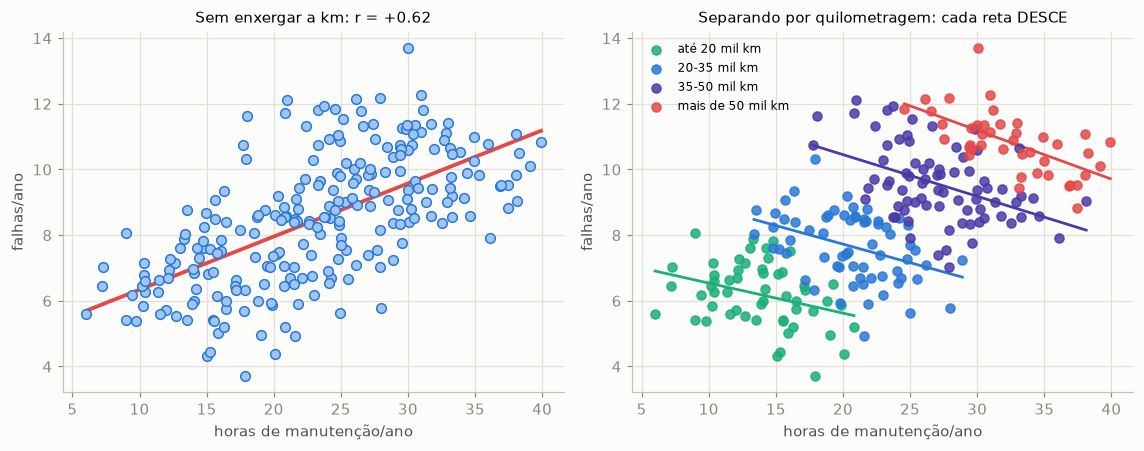

À esquerda, uma nuvem só e uma reta subindo. À direita, os mesmos pontos coloridos
pela variável escondida — e quatro retas descendo.

A reta vermelha da esquerda não está 'errada': ela descreve fielmente o que acontece
quando você compara viaturas QUE RODAM DIFERENTE. Só não serve para decidir nada.


In [4]:
# --- O mesmo fato, em gráfico: a cor revela o confundidor ---
fig, (e1, e2) = plt.subplots(1, 2, figsize=(10.5, 4.2))

e1.scatter(frota["manutencao_h"], frota["falhas"], color=COR["dados"],
           edgecolor=COR["reta"], s=40, zorder=3)
aa, bb = np.polyfit(frota["manutencao_h"], frota["falhas"], 1)
gx = np.linspace(frota["manutencao_h"].min(), frota["manutencao_h"].max(), 50)
e1.plot(gx, aa * gx + bb, color=COR["alerta"], linewidth=2.5)
e1.set_title(f"Sem enxergar a km: r = {r_bruto:+.2f}", fontsize=10)
e1.set_xlabel("horas de manutenção/ano"); e1.set_ylabel("falhas/ano")

cores_faixa = [COR["verdade"], COR["media"], COR["grupoA"], COR["alerta"]]
for (faixa, grupo), c in zip(frota.groupby("faixa_km", observed=True), cores_faixa):
    e2.scatter(grupo["manutencao_h"], grupo["falhas"], color=c, s=35, alpha=0.85,
               label=f"{faixa} km", zorder=3)
    if len(grupo) > 5:
        a2, b2 = np.polyfit(grupo["manutencao_h"], grupo["falhas"], 1)
        gx2 = np.linspace(grupo["manutencao_h"].min(), grupo["manutencao_h"].max(), 20)
        e2.plot(gx2, a2 * gx2 + b2, color=c, linewidth=1.8)
e2.set_title("Separando por quilometragem: cada reta DESCE", fontsize=10)
e2.set_xlabel("horas de manutenção/ano"); e2.set_ylabel("falhas/ano")
e2.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

print("À esquerda, uma nuvem só e uma reta subindo. À direita, os mesmos pontos coloridos")
print("pela variável escondida — e quatro retas descendo.")
print("\nA reta vermelha da esquerda não está 'errada': ela descreve fielmente o que acontece")
print("quando você compara viaturas QUE RODAM DIFERENTE. Só não serve para decidir nada.")

> **A ligação com o Módulo 5:** foi exatamente isto que a regressão múltipla fez na §2.2 daquele
> módulo, ao colocar a idade ao lado do treino. "Controlar por uma variável" é a versão
> algébrica de "olhar dentro de faixas parecidas".
>
> ⚠️ **E a limitação continua a mesma:** só dá para ajustar o confundidor que você **mediu**. Se
> a quilometragem não estivesse na planilha, a correlação bruta seria tudo o que existiria — e
> nada no resultado avisaria que ela está invertida. É por isso que "controlamos por diversas
> variáveis" **não** é sinônimo de "provamos a causa".

---
# ③ Paradoxo de Simpson

O confundimento na sua forma mais dramática: o agregado não apenas **enfraquece** a relação —
ele **inverte** o sinal em relação a todos os subgrupos.

> Dois programas de recondicionamento físico, A e B, aplicados a 350 militares cada. O comando
> vai adotar o de maior taxa de sucesso.

In [5]:
# --- Programa A × Programa B: por subgrupo e no total ---
dados = {
    #                 (sucessos, total)
    "A": {"casos leves": (81, 87),  "casos graves": (192, 263)},
    "B": {"casos leves": (234, 270), "casos graves": (55, 80)},
}

print(f"{'programa':<10} | {'casos leves':>18} | {'casos graves':>18} | {'TOTAL':>16}")
print("-" * 72)
for prog, grupos in dados.items():
    (sl, tl), (sg, tg) = grupos["casos leves"], grupos["casos graves"]
    st, tt = sl + sg, tl + tg
    print(f"{prog:<10} | {sl:>4}/{tl:<4} = {sl/tl:>6.1%} | {sg:>4}/{tg:<4} = {sg/tg:>6.1%} | "
          f"{st:>3}/{tt:<3} = {st/tt:>5.1%}")

print("\nPrograma A vence nos casos LEVES  (93,1% contra 86,7%)")
print("Programa A vence nos casos GRAVES (73,0% contra 68,8%)")
print("Programa B vence no TOTAL          (82,6% contra 78,0%)")
print("\nA é melhor nos dois grupos e pior no agregado. Não há erro de conta:")
print("confira as somas você mesmo.")

programa   |        casos leves |       casos graves |            TOTAL
------------------------------------------------------------------------
A          |   81/87   =  93.1% |  192/263  =  73.0% | 273/350 = 78.0%
B          |  234/270  =  86.7% |   55/80   =  68.8% | 289/350 = 82.6%

Programa A vence nos casos LEVES  (93,1% contra 86,7%)
Programa A vence nos casos GRAVES (73,0% contra 68,8%)
Programa B vence no TOTAL          (82,6% contra 78,0%)

A é melhor nos dois grupos e pior no agregado. Não há erro de conta:
confira as somas você mesmo.


### Como isso é possível

Olhe **quantos** casos de cada tipo cada programa recebeu:

| | casos leves | casos graves | % de graves |
|---|---|---|---|
| **Programa A** | 87 | 263 | **75%** |
| **Programa B** | 270 | 80 | **23%** |

O programa A recebeu majoritariamente os **casos graves** — que têm taxa de sucesso menor
**qualquer que seja o programa**. O total de A foi arrastado para baixo pela composição da
carteira, não pela qualidade do programa.

> ### ⚠️ Qual dos dois números é o certo?
> **Depende da pergunta — e essa é a parte incômoda.**
>
> - *"Qual programa devo aplicar ao próximo militar?"* → o **subgrupo**. A, sempre, seja o caso
>   leve ou grave.
> - *"Qual programa produziu mais recuperados no ano passado?"* → o **total**. Foi o B, e isso é
>   um fato histórico.
>
> A pergunta operacional quase sempre é a primeira. E há um teste que resolve a maioria dos
> casos: **a variável que separa os grupos veio ANTES do tratamento?** A gravidade do caso existe
> antes da escolha do programa, e influencia essa escolha — logo é confundidor, logo olhe os
> subgrupos.

---
# ④ Colisor: a correlação que você mesmo criou

O mecanismo mais contraintuitivo dos quatro — e o mais difícil de perceber, porque ele nasce de
uma decisão que parece puramente administrativa: **quem entra na base de dados**.

> Numa força especial, o processo seletivo aprova quem tem **desempenho físico alto OU
> capacidade técnica alta** (a soma precisa passar de um corte). Analisando **os aprovados**, o
> S1 encontra correlação **negativa** entre físico e técnica, e conclui: *"militares mais fortes
> tendem a ser tecnicamente mais fracos."*

**Antes de rodar:** na população geral, físico e técnica foram gerados **sem nenhuma relação**
entre si. O que o filtro de seleção vai fazer com isso?

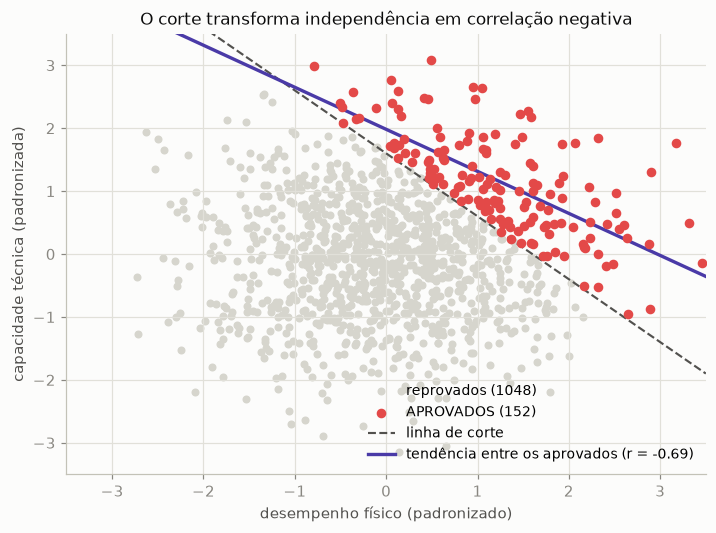

r na POPULAÇÃO inteira : +0.026   (nenhuma relação — como construímos)
r entre os APROVADOS   : -0.685   ('quanto mais forte, menos técnico')

O raciocínio que o dado sugere está certo DENTRO do grupo selecionado:
se um aprovado é fraco no físico, ele SÓ pode ter passado por ser muito bom na técnica.
Mas isso é uma propriedade do FILTRO, não dos militares.


In [6]:
# --- Independentes na população, correlacionados entre os aprovados ---
rng3 = np.random.default_rng(17)
NP = 1200

fisico  = rng3.normal(0, 1, NP)      # independentes de verdade:
tecnica = rng3.normal(0, 1, NP)      # nós os sorteamos separadamente

CORTE = 1.6
aprovado = (fisico + tecnica) > CORTE          # aprova quem é bom na SOMA

r_pop = stats.pearsonr(fisico, tecnica).statistic
r_sel = stats.pearsonr(fisico[aprovado], tecnica[aprovado]).statistic

plt.figure(figsize=(7.5, 5.2))
plt.scatter(fisico[~aprovado], tecnica[~aprovado], color="#d6d5cd", s=18,
            label=f"reprovados ({np.sum(~aprovado)})")
plt.scatter(fisico[aprovado], tecnica[aprovado], color=COR["alerta"], s=28, zorder=3,
            label=f"APROVADOS ({np.sum(aprovado)})")
gx = np.linspace(-3.5, 3.5, 10)
plt.plot(gx, CORTE - gx, color="#52514e", linestyle="--", linewidth=1.4, label="linha de corte")
a_s, b_s = np.polyfit(fisico[aprovado], tecnica[aprovado], 1)
plt.plot(gx, a_s * gx + b_s, color=COR["grupoA"], linewidth=2.2,
         label=f"tendência entre os aprovados (r = {r_sel:.2f})")
plt.xlim(-3.5, 3.5); plt.ylim(-3.5, 3.5)
plt.title("O corte transforma independência em correlação negativa", color="#0b0b0b", fontsize=11)
plt.xlabel("desempenho físico (padronizado)"); plt.ylabel("capacidade técnica (padronizada)")
plt.legend(frameon=False, fontsize=9)
plt.show()

print(f"r na POPULAÇÃO inteira : {r_pop:+.3f}   (nenhuma relação — como construímos)")
print(f"r entre os APROVADOS   : {r_sel:+.3f}   ('quanto mais forte, menos técnico')")
print("\nO raciocínio que o dado sugere está certo DENTRO do grupo selecionado:")
print("se um aprovado é fraco no físico, ele SÓ pode ter passado por ser muito bom na técnica.")
print("Mas isso é uma propriedade do FILTRO, não dos militares.")

### Por que isso se chama "colisor"

Físico e técnica são duas **causas** de uma mesma consequência: a aprovação. Quando você
condiciona a análise a essa consequência (olhando só os aprovados), você cria uma relação
artificial entre as causas. As duas setas "colidem" na aprovação — daí o nome.

> **A regra prática, e ela é curta:**
>
> - **Confundidor** (causa comum, vem **antes**) → você **deve** controlar/separar. Não fazer
>   isso enviesa.
> - **Colisor** (efeito comum, vem **depois**) → você **não pode** controlar/filtrar. Fazer isso
>   enviesa.
>
> Ou seja: "controlar por mais variáveis" pode **melhorar ou piorar** a análise, dependendo de a
> variável vir antes ou depois. Não existe "quanto mais controle, melhor".

Onde isso te pega: analisar só quem foi **aprovado**, só quem **sobreviveu**, só quem **respondeu
ao questionário**, só as viaturas que **não baixaram**, só os projetos que **foram aprovados**.
Toda vez que o filtro é um efeito das variáveis estudadas, a correlação encontrada é fabricada.

Esse é o mesmo mecanismo do viés do sobrevivente — que abre o **Módulo 7**.

---
# ⑤ O que autoriza falar em causa: o sorteio

Todos os problemas acima têm a mesma raiz: **quem recebeu o tratamento não é comparável a quem
não recebeu**. Quem treina mais já era mais motivado; quem recebeu manutenção já rodava mais.

Existe uma única ferramenta que resolve isso de forma geral, e ela é surpreendentemente simples:
**decidir quem recebe o tratamento por sorteio.**

O sorteio não torna os grupos idênticos — torna-os **comparáveis**, porque nenhuma característica
(medida **ou não medida**, conhecida **ou desconhecida**) tem como se concentrar sistematicamente
num dos lados.

**Antes de rodar:** vamos comparar a mesma pergunta respondida das duas formas, num mundo em que
sabemos que o efeito verdadeiro do treino extra é **−0,50 min**.

In [7]:
# --- Observação × sorteio, com o efeito verdadeiro conhecido ---
rng4 = np.random.default_rng(31)
NM = 600
EFEITO_REAL = -0.50            # minutos que o treino extra REALMENTE tira do tempo

motivacao = rng4.normal(0, 1, NM)          # não medida na prática! é o confundidor

# --- CENÁRIO 1: observacional — o militar ESCOLHE fazer o treino extra ---
faz_obs = motivacao > 0.25                                   # os mais motivados aderem
tempo_obs = 12.0 - 0.9 * motivacao + EFEITO_REAL * faz_obs + rng4.normal(0, 0.6, NM)

# --- CENÁRIO 2: experimental — o treino extra é SORTEADO ---
faz_exp = rng4.random(NM) < 0.5                              # moeda, ignora a motivação
tempo_exp = 12.0 - 0.9 * motivacao + EFEITO_REAL * faz_exp + rng4.normal(0, 0.6, NM)

print(f"EFEITO VERDADEIRO do treino extra: {EFEITO_REAL:+.2f} min\n")
print(f"{'como o grupo foi formado':<30} | {'efeito estimado':>16} | {'erro':>8}")
print("-" * 62)
for rotulo, faz, tempo in [("militar escolheu (observação)", faz_obs, tempo_obs),
                           ("sorteio (experimento)",         faz_exp, tempo_exp)]:
    est = tempo[faz].mean() - tempo[~faz].mean()
    print(f"{rotulo:<30} | {est:>+16.2f} | {est - EFEITO_REAL:>+8.2f}")

print("\nCONFERINDO se os grupos eram comparáveis (motivação média em cada um):")
print(f"  observação: fez = {motivacao[faz_obs].mean():+.2f} | não fez = {motivacao[~faz_obs].mean():+.2f}"
      f"  <-- MUITO diferentes")
print(f"  sorteio   : fez = {motivacao[faz_exp].mean():+.2f} | não fez = {motivacao[~faz_exp].mean():+.2f}"
      f"  <-- praticamente iguais")

print("\nA observação atribuiu ao treino um efeito MUITO maior que o real — porque comparou")
print("motivados com desmotivados. O sorteio acertou, sem nunca ter medido a motivação.")

EFEITO VERDADEIRO do treino extra: -0.50 min

como o grupo foi formado       |  efeito estimado |     erro
--------------------------------------------------------------
militar escolheu (observação)  |            -1.93 |    -1.43
sorteio (experimento)          |            -0.51 |    -0.01

CONFERINDO se os grupos eram comparáveis (motivação média em cada um):
  observação: fez = +0.96 | não fez = -0.65  <-- MUITO diferentes
  sorteio   : fez = +0.09 | não fez = +0.07  <-- praticamente iguais

A observação atribuiu ao treino um efeito MUITO maior que o real — porque comparou
motivados com desmotivados. O sorteio acertou, sem nunca ter medido a motivação.


### Quando não dá para sortear

Na vida real, sortear é frequentemente impossível — por ética, por custo ou por natureza do
problema (ninguém sorteia quem vai para o combate). Nesses casos existem desenhos
**quase-experimentais**, e o mínimo que se espera de um relatório honesto é:

| Recurso | O que faz |
|---|---|
| **Grupo de controle** (mesmo sem sorteio) | dá um "o que teria acontecido sem nada" |
| **Medida antes e depois** nos dois grupos | separa a tendência geral do efeito |
| **Controle dos confundidores medidos** | Módulo 5, §2.2 |
| **Declarar os não medidos** | honestidade sobre o que ficou de fora |

> E, sobretudo: **cuidado com a seleção pelo extremo**. Se o grupo tratado foi escolhido por ser
> o pior, parte da "melhora" é regressão à média (Módulo 5, §⑤) — e não precisa de nenhuma
> variável escondida para aparecer.

---
# ⑥ Decisão: o que reportar ao comando

| A pergunta real é... | Reporte | Por quê |
|---|---|---|
| "A causa B?" | **o desenho do estudo**, antes do número | é ele que autoriza, ou não (§⑤) |
| "os grupos eram comparáveis?" | as **características dos dois grupos** | é o teste de fumaça do confundimento (§②) |
| há subgrupos relevantes? | os **subgrupos separados** e o total | Simpson pode inverter tudo (§③) |
| a amostra passou por filtro? | **qual filtro, e quando** | filtro após o efeito = colisor (§④) |
| "controlamos várias variáveis" | **quais**, e quais **não** foram medidas | só se ajusta o que se mede |
| tratamento aplicado ao pior grupo | a **diferença contra controle** | regressão à média (Módulo 5, §⑤) |

### Três frases para levar

1. **Quatro motivos, uma correlação.** Causa é só um deles, e o número não distingue.
2. **Controlar variável vem antes; filtrar amostra vem depois.** Confundidor exige controle;
   colisor proíbe.
3. **Sorteio é a única defesa geral** — porque é a única que protege contra o que você **não**
   mediu.

---
# 🔻 Fechamento do Dia 2 · Por que isso importa para a IA

Você passou o dia inteiro estudando **relações entre variáveis**. Isso não é um pré-requisito
distante da inteligência artificial: é literalmente o que um modelo de IA faz.

Um modelo recebe variáveis de entrada e aprende a prever uma saída. **Ele é uma máquina de achar
correlação** — uma regressão do Módulo 5 com muito mais variáveis e muito mais flexibilidade, mas
com a mesma natureza. Por isso tudo o que você viu hoje se aplica a ele:

- **O modelo aprende correlação, nunca causa.** Ele pode acertar a previsão apoiado numa variável
  que não causa nada — o exemplo clássico da área é o modelo que "detectava tumor" e na verdade
  aprendera a reconhecer a **régua** que os médicos colocavam ao lado das lesões nas fotos.
- **"Variável mais importante" não é "causa".** Toda lista de importância que um modelo produz
  responde *"o que ajudou a prever"* — e o Módulo 6 inteiro é sobre por que isso não autoriza
  intervir naquela variável.
- **Simpson explica o modelo que vai bem no geral e mal num subgrupo.** O desempenho agregado
  pode esconder — e até inverter — o desempenho dentro de cada grupo.
- **O colisor explica dados de treino envenenados pela seleção.** Se a base contém apenas os
  aprovados, os sobreviventes ou os que responderam, o modelo aprende as relações **daquele
  filtro**, e não as da realidade em que ele vai operar.
- **Prever ≠ decidir.** Um modelo excelente para prever quem vai falhar não diz o que fazer para
  evitar a falha. Essa segunda pergunta é causal, e exige o §⑤.

> **A frase para levar do dia:** um modelo de IA é a maior máquina de correlação já construída —
> e por isso mesmo herda, em escala, todas as armadilhas deste dia.

---
# ⑦ Exercícios

**Exercício 1 — Classifique o mecanismo.**

Para cada afirmação, diga qual dos quatro motivos da §① é o mais provável, e qual seção do módulo
trata dele:

1. "Militares que usam joelheira se lesionam mais. A joelheira enfraquece a articulação."
2. "Entre os aprovados no curso de comandos, quem tirou nota alta em tiro tirou nota baixa em
   navegação."
3. "As OMs com mais denúncias de assédio são as que mais investem em canais de denúncia."
4. "O consumo de sorvete na guarnição e o número de afogamentos sobem juntos."
5. "Nossa nova doutrina de manutenção foi aplicada nas 10 piores viaturas, e elas melhoraram 30%."

**Exercício 2 — Mude um parâmetro.**

Na célula da §④, mude o `CORTE` para 0,5 (seleção frouxa) e depois para 2,5 (seleção durísssima).
Anote o `r` entre os aprovados nos dois casos. Pergunta: quanto mais **seletivo** o filtro, o
viés do colisor aumenta ou diminui?

**Exercício 3 — Conserte o erro (conceitual, não de sintaxe).**

Um estudo conclui:

> "Analisamos 4.000 militares. Controlando por idade, posto, tempo de serviço, OM, estado civil e
> escolaridade, encontramos que o uso do aplicativo de treino está associado a 1,2 min a menos na
> corrida (p < 0,001). Dado o grande número de variáveis controladas e o tamanho da amostra,
> concluímos que o aplicativo **causa** a melhora e recomendamos a compra de licenças para toda a
> Força."

Aponte **três** falhas no argumento. *(Dica: o que 6 controles e n = 4.000 **não** resolvem?)*

**Exercício 4 — Desenhe o estudo (discussão em grupo).**

O comando quer saber se o novo simulador de tiro melhora o desempenho real no estande.

1. Desenhe o estudo **observacional** mais fácil de fazer. Que confundidores você esperaria?
2. Desenhe o estudo com **sorteio**. O que exatamente seria sorteado?
3. Que objeções práticas/éticas o sorteio enfrentaria nesta OM, e como contorná-las?
4. Se o comando insistir em treinar primeiro os **piores atiradores**, que erro do Módulo 5 vai
   contaminar o resultado — e como separá-lo do efeito real do simulador?

---
## Resumo do módulo

| Mecanismo | O que é | Como se defender |
|---|---|---|
| **Causalidade reversa** | B é que causa A | ordem no tempo |
| **Confundimento** | C causa A e B | controlar/separar por C (vem **antes**) |
| **Paradoxo de Simpson** | o agregado inverte os subgrupos | olhar os subgrupos; testar a ordem temporal |
| **Colisor** | filtrar por um **efeito** comum | **não** condicionar em variável posterior |
| **Tendência comum** | as duas só crescem com o tempo | comparar variações, não níveis |
| **Aleatorização** | sorteio de quem recebe | única defesa contra o **não medido** |

- **Quatro motivos produzem a mesma correlação.** O dado observacional não os distingue.
- **Antes → controle. Depois → não filtre.** Essa é a regra que separa confundidor de colisor.
- **Só o sorteio protege do que você não mediu** — e é por isso que ele vale tanto.

➡️ **Fim do Dia 2.** Você saiu de "descrever uma variável" (Dia 1) para "relacionar duas" — e
descobriu que relacionar é fácil e **interpretar** é que é difícil. Em todo o caminho, porém,
tratamos os dados como se fossem a realidade inteira. **E se a amostra que chegou até você já
estiver torta?** É o Dia 3: de onde vieram os dados, quanta confiança o número merece — e como
ler, com esses olhos, um resultado de IA.